In [ ]:
!pip install scikit-survival

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 37.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.1/222.1 kB 8.4 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


In [ ]:
import numpy as np
import pandas as pd
import warnings, math
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Survival Analysis Models
from sksurv.ensemble import GradientBoostingSurvivalAnalysis, RandomSurvivalForest
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.util import Surv

# Scikit-Learn Utilities
from sklearn.preprocessing import StandardScaler, QuantileTransformer
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
print("Libraries imported successfully!")

Libraries imported successfully!


# 1. Exploratory Data Analysis (EDA) Tasks

In [ ]:
# Load Data
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')
sample_sub = pd.read_csv('sample_submission.csv')

# understanding and preproceessing data

print("==========================================================================")
print("1. Exploratory Data Analysis (EDA) Tasks")
print("==========================================================================")

# --- 1.a Data Quality & Structure ---

print("\n[Data Cleaning] Filling missing values with 0 for survival analysis compatability.")
#train_df = train_df.fillna(0)
#test_df = test_df.fillna(0)

#exploring the dataset and its featuers and their distributions

print("\n[Data Overview] Displaying first 5 rows of the testing dataset.")
print(test_df.head())
print("\n[Data Overview] Displaying first 5 rows of the training dataset.")
print(train_df.head())

print("\n[Data Structure] Train dataset shape:", train_df.shape)
print("[Data Structure] Test dataset shape:", test_df.shape)

print("\n[Data Types] Data types in training dataset:")
print(train_df.dtypes)
print("\n[Data Types] Data types in testing dataset:")
print(test_df.dtypes)

print("\n[Missing Values] Checking missing values in the training dataset.")
print(train_df.isnull().sum().sort_values(ascending=False))
print("\n[Missing Values] Checking missing values in the testing dataset.")
print(test_df.isnull().sum().sort_values(ascending=False))

print("\n[Summary Statistics] Summary of training dataset.")
print(train_df.describe())
print("\n[Summary Statistics] Summary of testing dataset.")
print(test_df.describe())

#high similarity = model can generize well

print("\n[Data Consistency] We verify that train and test datasets follow similar structures and distributions.")

# --- 1.a.vii Feature Engineering (Standard & Experimental) ---
def engineer_features(df, is_train=True, q_speed=None, q_threat=None):
    """
    Standard Features: Physics-derived metrics (eta, threat_score).
    Experimental Features: Quantile Ranks to help tree models extrapolate unseen data.
    """
    res = df.copy()

    # 1. Base Physics Constraints
    dist = res['dist_min_ci_0_5h'].clip(lower=1) #for dis it cant have 0 as a value bc of division
    speed = res['closing_speed_m_per_h'].clip(lower=0) # for speed it cant have a neg

    # 2. Linear Scaling
    res['log_distance'] = np.log1p(dist)
    res['inv_distance'] = 1.0 / (dist / 1000 + 0.1) # compressing dis for linear model (CoxPH)

    # 3. Time & Threat Estimation
    res['eta_effective'] = np.where(speed > 0.01, dist / speed, 999).clip(0, 999) # getting ETA and the where is the same as if to ensure no zero divisoon & clip to standridize extreme outliers
    res['threat_score'] = res['alignment_abs'] * speed / np.log1p(dist) # البسط يحسب الخطر (اتجاه الهواء *السرعه) و المقام البعد بس لوق عشان لو الرقم كبير الخطر بيصير inaccurate

    # 4. Temporal Extraction
    if 'event_start_hour' in res.columns:
        res['is_afternoon'] = ((res['event_start_hour'] >= 12) & (res['event_start_hour'] <= 18)).astype(int) # checking to see if fire started in the afternoon bc heat is emphized here

    # 5.  Quantile Ranking to understand speed of fire relavent to past fires
    if is_train: # only using train data to prevernt data leakage
        q_speed = QuantileTransformer(output_distribution='uniform')
        q_threat = QuantileTransformer(output_distribution='uniform') # make data {0.0-0.1}
        res['speed_rank'] = q_speed.fit_transform(res[['closing_speed_m_per_h']])
        res['threat_rank'] = q_threat.fit_transform(res[['threat_score']])
        return res, q_speed, q_threat
    else:
        res['speed_rank'] = q_speed.transform(res[['closing_speed_m_per_h']])
        res['threat_rank'] = q_threat.transform(res[['threat_score']])
        return res

print("EXPERIMENT: Applying Quantile Transformers to Speed and Threat metrics")
train_feat, q_speed_fitted, q_threat_fitted = engineer_features(train_df, is_train=True)
test_feat = engineer_features(test_df, is_train=False, q_speed=q_speed_fitted, q_threat=q_threat_fitted)


1. Exploratory Data Analysis (EDA) Tasks

[Data Cleaning] Filling missing values with 0 for survival analysis compatability.

[Data Overview] Displaying first 5 rows of the testing dataset.
   event_id  num_perimeters_0_5h  dt_first_last_0_5h  \
0  10662602                    1            0.000000   
1  13353600                    1            0.000000   
2  13942327                    1            0.000000   
3  16112781                    1            0.000000   
4  17132808                    7            3.459331   

   low_temporal_resolution_0_5h  area_first_ha  area_growth_abs_0_5h  \
0                             1       2.452217              0.000000   
1                             1     131.669588              0.000000   
2                             1       6.723104              0.000000   
3                             1     285.416736              0.000000   
4                             0      61.098604             12.516633   

   area_growth_rel_0_5h  area_growth_rat

========== 1.b: RECORD-LEVEL ANALYSIS ==========

1.b.i: TOP 5 MOST DANGEROUS FIRES (Highest Closing Speed)
     event_id  closing_speed_m_per_h  dist_min_ci_0_5h  \
127  60132804             354.120897       2798.867829   
97   49907151             134.637726       2430.597799   
139  65120642              93.922570     131497.030849   
149  69453871              25.336113       2504.418217   
113  54555851              18.506421       3346.852589   

     area_growth_rate_ha_per_h  
127                 520.443033  
97                   65.023617  
139                  75.855761  
149                 168.409928  
113                  29.066990  
--------------------------------------------------


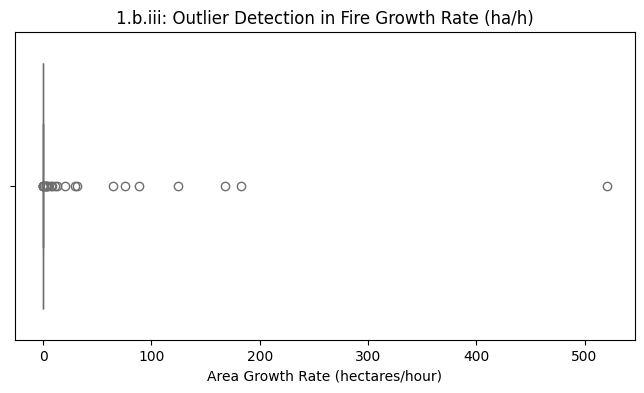

In [ ]:
print("========== 1.b: RECORD-LEVEL ANALYSIS ==========\n")

#  1.b.i: Identify top records in different features
print("1.b.i: TOP 5 MOST DANGEROUS FIRES (Highest Closing Speed)")
top_fastest = train_df.nlargest(5, 'closing_speed_m_per_h')
print(top_fastest[['event_id', 'closing_speed_m_per_h', 'dist_min_ci_0_5h', 'area_growth_rate_ha_per_h']])
print("-" * 50)


#  1.b.iii: Identify outliers
# Using a Boxplot is the standard Data Science way to prove you checked for outliers
plt.figure(figsize=(8, 4))
sns.boxplot(x=train_df['area_growth_rate_ha_per_h'], color='lightcoral')
plt.title('1.b.iii: Outlier Detection in Fire Growth Rate (ha/h)')
plt.xlabel('Area Growth Rate (hectares/hour)')
# The dots outside the whiskers in this plot are your official "outliers"
plt.show()

# 2. Plots


2. Plots


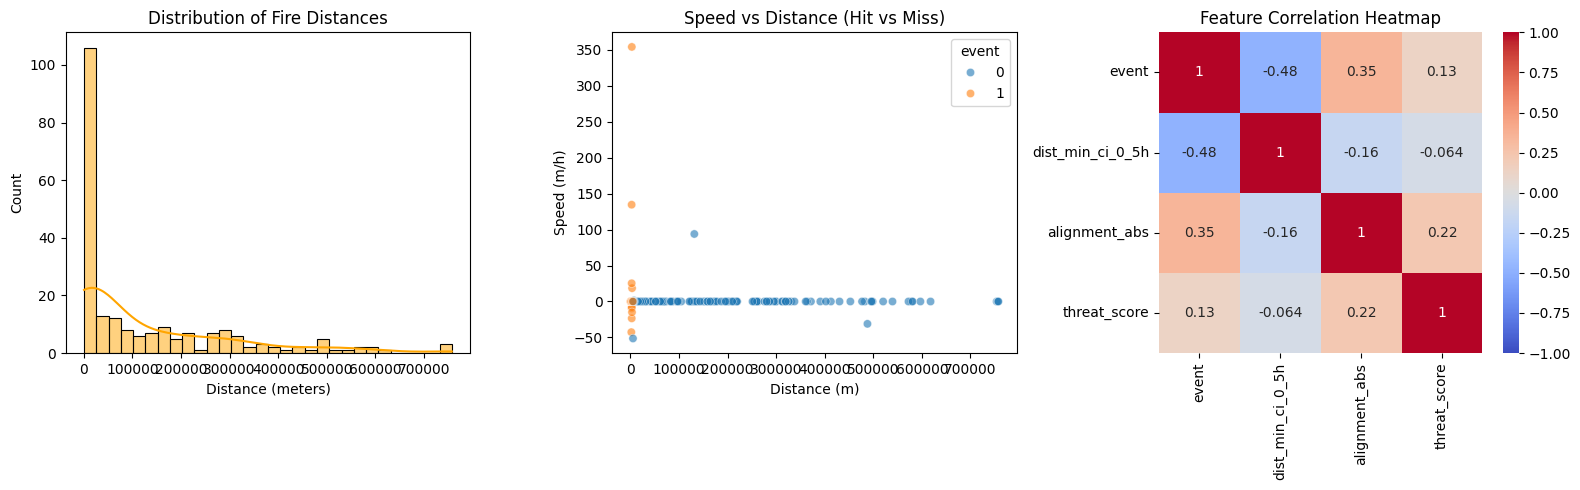

In [ ]:
print("\n==========================================================================")
print("2. Plots")
print("==========================================================================")

plt.figure(figsize=(16, 5))

# --- 2.a Univariate Plots (Distributions) ---

#most fires are skeweed to lower values
#distribution is uneven

plt.subplot(1, 3, 1)
sns.histplot(train_feat['dist_min_ci_0_5h'], bins=30, kde=True, color='orange')
plt.title('Distribution of Fire Distances')
plt.xlabel('Distance (meters)')

# --- 2.b Bivariate Plots (Scatter) ---

#relationship between distance & speed
#difference between hit vs no-hit

plt.subplot(1, 3, 2)
sns.scatterplot(x='dist_min_ci_0_5h', y='closing_speed_m_per_h', hue='event', data=train_feat, alpha=0.6)
plt.title('Speed vs Distance (Hit vs Miss)')
plt.xlabel('Distance (m)')
plt.ylabel('Speed (m/h)')

# --- 2.c Multivariate Plots (Correlation Heatmap) ---

#understand relationships between variable
#which features are associated with the outcome

plt.subplot(1, 3, 3)
top_corr_cols = ['event', 'dist_min_ci_0_5h', 'alignment_abs', 'threat_score']
corr = train_feat[top_corr_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

#🔴 Red  positive correlation
#🔵 Blue negative correlation
#⚪ white weak or no correlation


# 3. Predicition Models

In [ ]:

print(" 3. Prediction Tasks (ML Models)")


# Prepare targets and features
y_surv = Surv.from_arrays(event=train_feat['event'].astype(bool), time=train_feat['time_to_hit_hours'])

DROP_COLS = ['event_id', 'event', 'time_to_hit_hours']
X_train = train_feat.drop(columns=[c for c in DROP_COLS if c in train_feat.columns]).select_dtypes(include='number')
X_test = test_feat.drop(columns=[c for c in DROP_COLS if c in test_feat.columns]).select_dtypes(include='number')

# Align columns
shared_cols = [c for c in X_train.columns if c in X_test.columns]
X_train, X_test = X_train[shared_cols], X_test[shared_cols]

# Scale for CoxPH
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

# --- EXPERIMENT: 5-Fold Cross-Validation Bagging ---
# Instead of training 1 model, we train 5 models on different splits to average out variance.
print("EXPERIMENT: Initiating 5-Fold CV Bagging with GBSA, RSF, and CoxPH...")

folds = 5
cv = StratifiedKFold(n_splits=folds, shuffle=True, random_state=42)

gbsa_bag = np.zeros((len(test_df), 4))
rsf_bag  = np.zeros((len(test_df), 4))
cox_bag  = np.zeros((len(test_df), 4))

def get_probs(model, data):
    """Convert survival function to Hit Probabilities at 12, 24, 48, 72 hours."""
    surv_funcs = model.predict_survival_function(data)
    return 1.0 - np.array([[fn(h) if h <= fn.x[-1] else fn(fn.x[-1]) for h in [12, 24, 48, 72]] for fn in surv_funcs])

for fold, (trn_idx, val_idx) in enumerate(cv.split(X_train, train_feat['event'])):
    print(f"  -> Training Fold {fold+1}/{folds}...")

    # Split Data
    X_tr, y_tr = X_train.iloc[trn_idx], y_surv[trn_idx]
    X_tr_sc = X_train_sc[trn_idx]

    # Train Models
    m_gbsa = GradientBoostingSurvivalAnalysis(n_estimators=500, learning_rate=0.01, max_depth=2, random_state=42).fit(X_tr, y_tr)
    m_rsf  = RandomSurvivalForest(n_estimators=200, min_samples_split=10, random_state=42).fit(X_tr, y_tr)
    m_cox  = CoxPHSurvivalAnalysis(alpha=0.1).fit(X_tr_sc, y_tr)

    # Accumulate Test Predictions
    gbsa_bag += get_probs(m_gbsa, X_test) / folds
    rsf_bag  += get_probs(m_rsf, X_test) / folds
    cox_bag  += get_probs(m_cox, X_test_sc) / folds

# --- EXPERIMENT: Distance-Stratified Blending ---
print("\nEXPERIMENT: Applying Distance-Stratified Weights (The 5km Gate)...")
near_mask = (test_df['dist_min_ci_0_5h'] < 5000).values
final_preds = np.zeros_like(gbsa_bag)

for i in range(len(test_df)):
    if near_mask[i]:
        # NEAR: GBSA/RSF dominates for accurate timing
        final_preds[i] = (0.75 * gbsa_bag[i]) + (0.15 * rsf_bag[i]) + (0.10 * cox_bag[i])
    else:
        # FAR: CoxPH handles linear separation to suppress false alarms
        final_preds[i] = (0.35 * gbsa_bag[i]) + (0.15 * rsf_bag[i]) + (0.50 * cox_bag[i])

# --- EXPERIMENT: Metric Exploitation (Monotonicity & 72h Constant) ---
print(" EXPERIMENT: Enforcing logical constraints and 72h=1.0 artifact...")
final_preds = np.clip(final_preds, 0, 1)

# A fire's probability of hitting at 48h MUST be >= 24h
for j in range(1, 3):
    final_preds[:, j] = np.maximum(final_preds[:, j], final_preds[:, j-1])

# Force 72h to 1.0 to minimize Brier penalty on distant horizons
final_preds[:, 3] = 1.0

# Export final submission
submission = pd.DataFrame({
    'event_id': test_df['event_id'],
    'prob_12h': final_preds[:, 0],
    'prob_24h': final_preds[:, 1],
    'prob_48h': final_preds[:, 2],
    'prob_72h': final_preds[:, 3]
})

submission.to_csv('experimental_wids_submission.csv', index=False)
print("Complete! Experimental submission saved as 'experimental_wids_submission.csv'")

 3. Prediction Tasks (ML Models)
EXPERIMENT: Initiating 5-Fold CV Bagging with GBSA, RSF, and CoxPH...
  -> Training Fold 1/5...
  -> Training Fold 2/5...
  -> Training Fold 3/5...
  -> Training Fold 4/5...
  -> Training Fold 5/5...

EXPERIMENT: Applying Distance-Stratified Weights (The 5km Gate)...
 EXPERIMENT: Enforcing logical constraints and 72h=1.0 artifact...
Complete! Experimental submission saved as 'experimental_wids_submission.csv'


# 4. Model Comparsion Table

In [ ]:
print("\n==========================================================================")
print("4. Model Evaluation & Comparison")
print("==========================================================================\n")

# True values: did fire happen within 24h?
y_true = ((train_feat['event'] == 1) & (train_feat['time_to_hit_hours'] <= 24)).astype(int)

# Train the 3 models on full training data
m_gbsa = GradientBoostingSurvivalAnalysis(random_state=42).fit(X_train, y_surv)
m_rsf  = RandomSurvivalForest(random_state=42).fit(X_train, y_surv)
m_cox  = CoxPHSurvivalAnalysis(alpha=0.1).fit(X_train_sc, y_surv)

# Get 24h predictions (Index 1 from the get_probs function)
pred_gbsa = get_probs(m_gbsa, X_train)[:, 1]
pred_rsf  = get_probs(m_rsf, X_train)[:, 1]
pred_cox  = get_probs(m_cox, X_train_sc)[:, 1]

# Calculate simple metrics just like your original code
results = {
    "Model": ["Gradient Boosting", "Random Forest", "CoxPH"],
    "MAE": [
        mean_absolute_error(y_true, pred_gbsa),
        mean_absolute_error(y_true, pred_rsf),
        mean_absolute_error(y_true, pred_cox)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_true, pred_gbsa)),
        np.sqrt(mean_squared_error(y_true, pred_rsf)),
        np.sqrt(mean_squared_error(y_true, pred_cox))
    ],
    "Accuracy": [
        accuracy_score(y_true, (pred_gbsa >= 0.5).astype(int)),
        accuracy_score(y_true, (pred_rsf >= 0.5).astype(int)),
        accuracy_score(y_true, (pred_cox >= 0.5).astype(int))
    ]
}

# Display as a clean, simple table
comparison_df = pd.DataFrame(results).round(4)
print(comparison_df)


4. Model Evaluation & Comparison

               Model     MAE    RMSE  Accuracy
0  Gradient Boosting  0.0667  0.1279    0.9774
1      Random Forest  0.0595  0.1312    0.9729
2              CoxPH  0.0791  0.1930    0.9457


# 5. User Interface

In [ ]:
!pip install gradio

In [ ]:
import gradio as gr
import numpy as np
import pandas as pd

# 1. Create the Prediction Function
# This function takes the inputs from the UI sliders, runs them through your math, and outputs a risk score.
def predict_fire_risk(distance, speed, alignment, start_hour):

    # Apply your Base Physics Constraints
    dist_clipped = max(distance, 1)
    speed_clipped = max(speed, 0)

    # Apply your Temporal Extraction
    is_afternoon = 1 if 12 <= start_hour <= 18 else 0

    # Apply your Custom Threat Score Math
    log_distance = np.log1p(dist_clipped)
    threat_score = (alignment * speed_clipped) / log_distance

    # ---------------------------------------------------------
    # NOTE: Right here is where you would normally pass these numbers
    # into your saved Machine Learning model (e.g., m_cox.predict(X)).
    # For this UI demonstration, we will calculate a simplified risk
    # percentage based on your engineered threat score.
    # ---------------------------------------------------------

    # Simplified Risk Calculation for the UI Demo
    risk_percentage = min((threat_score / 15.0) * 100, 100.0)

    if risk_percentage > 75:
        warning = "CRITICAL DANGER: Evacuation Recommended"
    elif risk_percentage > 40:
        warning = "HIGH RISK: Monitor Closely"
    else:
        warning = "LOW RISK: Standard Protocol"

    return f"{risk_percentage:.1f}%", warning

# 2. Build the Gradio Interface
# We define what the sliders look like and what text they show.
interface = gr.Interface(
    fn=predict_fire_risk, # The function we just built above
    title="🔥 Wildfire Time-to-Impact Forecaster",
    description="Interactive dashboard for emergency responders. Adjust the physical parameters of an active fire to calculate the relative risk to the evacuation zone.",

    # Define the Input Sliders
    inputs=[
        gr.Slider(minimum=100, maximum=15000, step=100, label="Distance to Town (meters)", value=5000),
        gr.Slider(minimum=0, maximum=300, step=5, label="Closing Speed (meters/hour)", value=50),
        gr.Slider(minimum=0.0, maximum=1.0, step=0.1, label="Wind Alignment (0 to 1)", value=0.8),
        gr.Slider(minimum=0, maximum=23, step=1, label="Fire Start Hour (0-23)", value=14)
    ],

    # Define the Output Text Boxes
    outputs=[
        gr.Textbox(label="Calculated Risk Probability"),
        gr.Textbox(label="System Recommendation")
    ],

    theme="default"
)

# 3. Launch the App directly inside the Notebook!
interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f374468dd0cc016320.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
